## 1. Imports & Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker

try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    print('Plotly not installed — run: pip install plotly')
    PLOTLY_AVAILABLE = False

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

PALETTE = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
BURNOUT_ORDER = ['Low', 'Medium', 'High']

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#ccccee',
    'xtick.color':      '#aaaacc',
    'ytick.color':      '#aaaacc',
    'text.color':       '#ddddff',
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'grid.alpha':        0.5,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight': 'bold',
})


## 2. Data Loading & Exploration

In [3]:
CSV_PATH = 'developer_burnout_dataset_7000.csv'  
df_raw = pd.read_csv(CSV_PATH)

print(f'Shape : {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(10)

Shape : (7000, 12)
Columns: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level', 'burnout_level']


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low
5,40.0,2.0,10.25,6.78,0.0,19.0,27.0,4.0,15.15,0.78,51.06,Medium
6,26.0,NaN,6.53,7.60,6.0,4.0,11.0,9.0,9.38,0.54,39.09,Medium
7,38.0,0.0,10.69,5.25,5.0,12.0,2.0,2.0,14.58,0.10,77.68,High
8,42.0,18.0,11.47,4.79,4.0,11.0,25.0,1.0,14.54,1.53,73.56,High
9,30.0,17.0,13.16,5.39,3.0,0.0,3.0,3.0,14.44,0.58,46.78,Medium


In [4]:
print(df_raw.dtypes)
print(df_raw.isnull().sum())
print(f'\nTotal nulls : {df_raw.isnull().sum().sum()}')
print(f'Null rows   : {df_raw.isnull().any(axis=1).sum()}')

age                 float64
experience_years    float64
daily_work_hours    float64
sleep_hours         float64
caffeine_intake     float64
bugs_per_day        float64
commits_per_day     float64
meetings_per_day    float64
screen_time         float64
exercise_hours      float64
stress_level        float64
burnout_level        object
dtype: object
age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64

Total nulls : 1680
Null rows   : 1510


In [5]:
df_raw.describe(include='all')

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
count,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3485
mean,32.129446,9.581050,9.000277,6.485638,3.540671,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825,NaN
std,7.230254,5.760972,2.863944,1.445008,2.283445,5.751664,8.669846,2.856766,3.091204,0.576708,23.446656,NaN
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000,NaN
25%,26.000000,5.000000,6.560000,5.220000,2.000000,5.000000,7.000000,2.000000,9.460000,0.510000,36.587500,NaN
50%,32.000000,10.000000,8.990000,6.460000,4.000000,9.000000,14.000000,5.000000,12.020000,1.020000,53.795000,NaN
75%,38.000000,15.000000,11.422500,7.740000,6.000000,14.000000,22.000000,7.000000,14.422500,1.510000,70.800000,NaN


In [6]:
print(df_raw['burnout_level'].value_counts())
print('\nUnique values:', df_raw['burnout_level'].unique())

burnout_level
Medium    3485
High      1782
Low       1593
Name: count, dtype: int64

Unique values: ['Medium' 'High' 'Low' nan]


## 3. Data Cleaning & Preprocessing

In [7]:
df = df_raw.copy()

before = len(df)
df.dropna(how='all', inplace=True)
print(f'Fully-null rows removed : {before - len(df)}')

num_cols = df.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    median = df[col].median()
    missing = df[col].isnull().sum()
    if missing > 0:
        df[col].fillna(median, inplace=True)
        print(f'  {col}: imputed {missing} nulls with median={median:.2f}')

if df['burnout_level'].isnull().any():
    mode_val = df['burnout_level'].mode()[0]
    df['burnout_level'].fillna(mode_val, inplace=True)
    print(f'  burnout_level: imputed nulls with mode={mode_val}')

df['burnout_level'] = df['burnout_level'].str.strip().str.capitalize()
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 3*IQR, Q3 + 3*IQR
    clipped = ((df[col] < lo) | (df[col] > hi)).sum()
    if clipped:
        df[col] = df[col].clip(lo, hi)
        print(f'  {col}: clipped {clipped} extreme values')

print(f'\nCleaned shape: {df.shape}')
print('Remaining nulls:', df.isnull().sum().sum())

Fully-null rows removed : 0
  age: imputed 140 nulls with median=32.00
  experience_years: imputed 140 nulls with median=10.00
  daily_work_hours: imputed 140 nulls with median=8.99
  sleep_hours: imputed 140 nulls with median=6.46
  caffeine_intake: imputed 140 nulls with median=4.00
  bugs_per_day: imputed 140 nulls with median=9.00
  commits_per_day: imputed 140 nulls with median=14.00
  meetings_per_day: imputed 140 nulls with median=5.00
  screen_time: imputed 140 nulls with median=12.02
  exercise_hours: imputed 140 nulls with median=1.02
  stress_level: imputed 140 nulls with median=53.80
  burnout_level: imputed nulls with mode=Medium

Cleaned shape: (7000, 12)
Remaining nulls: 0


In [8]:
df['work_life_balance'] = (df['sleep_hours'] + df['exercise_hours']) / (
    df['daily_work_hours'] + df['screen_time'] + 1e-6
)

df['productivity_ratio'] = (df['commits_per_day']) / (
    df['bugs_per_day'] + df['meetings_per_day'] + 1
)
df['cognitive_load'] = (
    df['bugs_per_day'] * 2 +
    df['meetings_per_day'] * 1.5 +
    df['daily_work_hours']
)
df['caffeine_per_sleep'] = df['caffeine_intake'] / (df['sleep_hours'] + 1e-6)

df['exp_tier'] = pd.cut(
    df['experience_years'],
    bins=[-1, 2, 7, 14, 20],
    labels=['Junior', 'Mid', 'Senior', 'Principal']
)

df['age_group'] = pd.cut(
    df['age'],
    bins=[19, 25, 30, 35, 40, 45],
    labels=['20-25', '26-30', '31-35', '36-40', '41-44']
)

print('New features added:')
new_feats = ['work_life_balance','productivity_ratio','cognitive_load','caffeine_per_sleep','exp_tier','age_group']
print(df[new_feats].describe())

New features added:
       work_life_balance  productivity_ratio  cognitive_load  \
count        7000.000000         7000.000000     7000.000000   
mean            0.389202            1.328431       34.777286   
std             0.147815            1.745056       12.552205   
min             0.134089            0.000000        5.130000   
25%             0.280978            0.466667       25.007500   
50%             0.356796            1.000000       34.675000   
75%             0.470219            1.583333       44.722500   
max             1.071572           29.000000       64.890000   

       caffeine_per_sleep  
count         7000.000000  
mean             0.577868  
std              0.403756  
min              0.000000  
25%              0.237530  
50%              0.556328  
75%              0.856164  
max              1.745635  


## 4. Exploratory Data Analysis — Matplotlib Visualisations

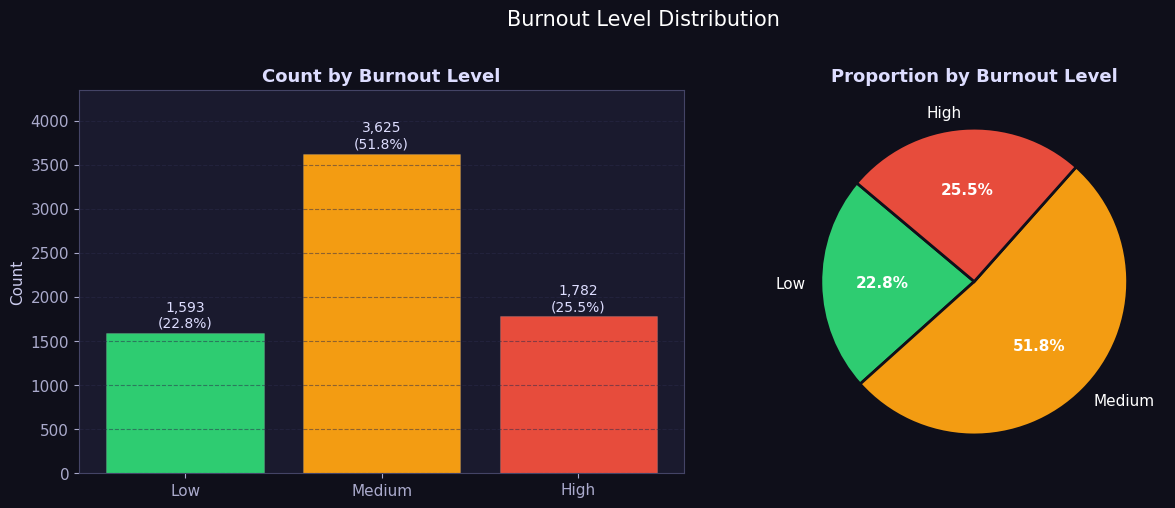

Saved: plot_01_burnout_distribution.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Burnout Level Distribution', fontsize=15, color='#ffffff', y=1.01)

counts = df['burnout_level'].value_counts().reindex(BURNOUT_ORDER)
colors = [PALETTE[b] for b in BURNOUT_ORDER]

axes[0].bar(BURNOUT_ORDER, counts.values, color=colors, edgecolor='#ffffff22', linewidth=0.8)
for i, (cat, val) in enumerate(zip(BURNOUT_ORDER, counts.values)):
    axes[0].text(i, val + 30, f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, color='#ddddff')
axes[0].set_title('Count by Burnout Level')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].grid(axis='y')

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=BURNOUT_ORDER, colors=colors,
    autopct='%1.1f%%', startangle=140,
    textprops={'color': '#ffffff', 'fontsize': 11},
    wedgeprops={'edgecolor': '#0f0f1a', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Proportion by Burnout Level')

plt.tight_layout()
plt.savefig('plot_01_burnout_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_01_burnout_distribution.png')

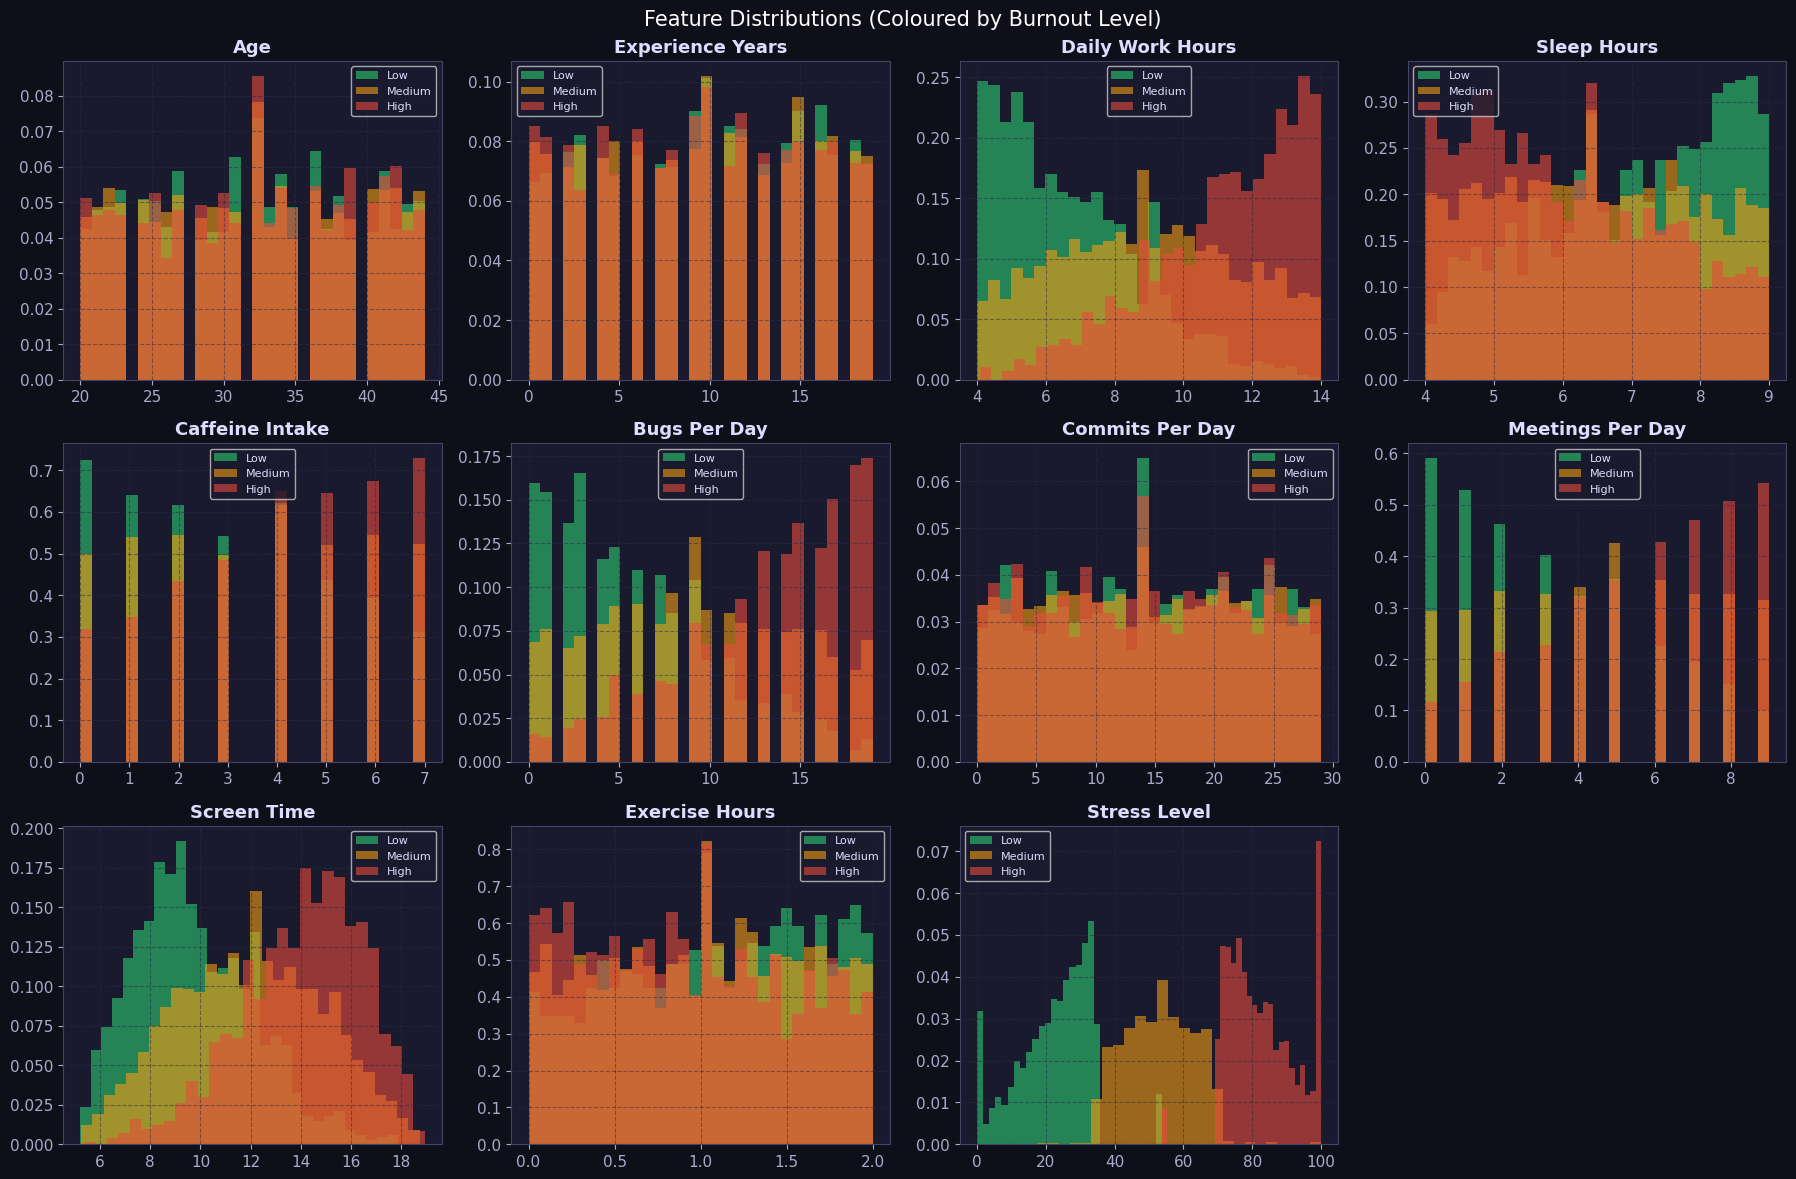

Saved: plot_02_feature_histograms.png


In [10]:
base_cols = ['age','experience_years','daily_work_hours','sleep_hours',
             'caffeine_intake','bugs_per_day','commits_per_day',
             'meetings_per_day','screen_time','exercise_hours','stress_level']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Feature Distributions (Coloured by Burnout Level)', fontsize=15, color='#ffffff')
axes = axes.flatten()

for i, col in enumerate(base_cols):
    ax = axes[i]
    for level in BURNOUT_ORDER:
        subset = df[df['burnout_level'] == level][col]
        ax.hist(subset, bins=30, alpha=0.6, color=PALETTE[level],
                label=level, edgecolor='none', density=True)
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(fontsize=8)
    ax.grid(True)

axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('plot_02_feature_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_02_feature_histograms.png')

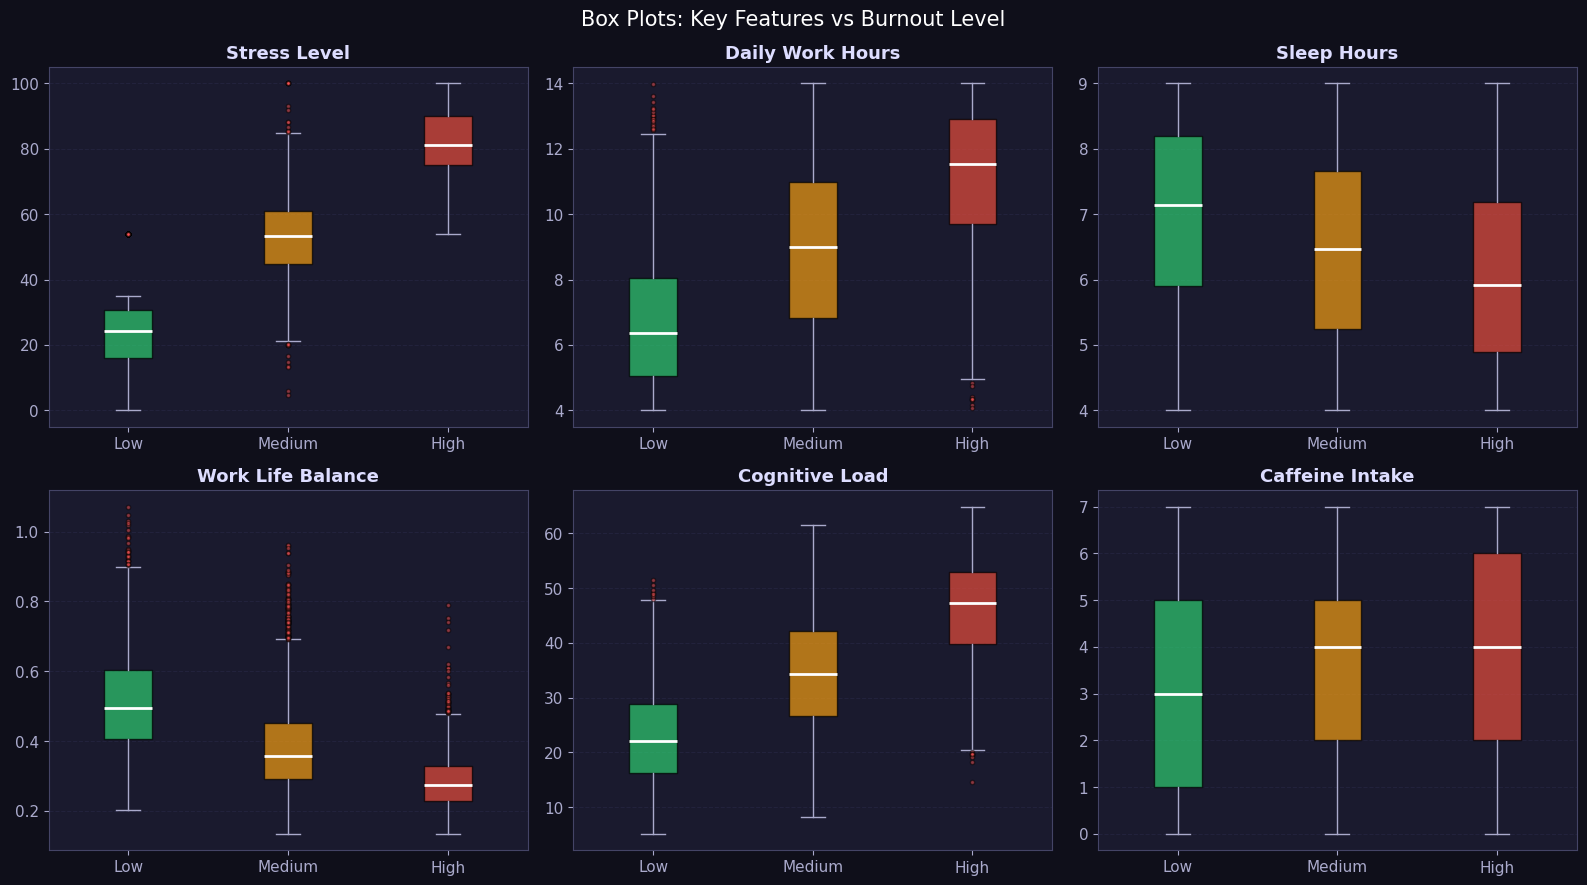

Saved: plot_03_boxplots.png


In [11]:
key_cols = ['stress_level','daily_work_hours','sleep_hours',
            'work_life_balance','cognitive_load','caffeine_intake']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Box Plots: Key Features vs Burnout Level', fontsize=15, color='#ffffff')
axes = axes.flatten()

for i, col in enumerate(key_cols):
    ax = axes[i]
    data_by_level = [df[df['burnout_level'] == lvl][col].dropna().values for lvl in BURNOUT_ORDER]
    bp = ax.boxplot(data_by_level, patch_artist=True,
                    medianprops={'color': '#ffffff', 'linewidth': 2},
                    whiskerprops={'color': '#aaaacc'},
                    capprops={'color': '#aaaacc'},
                    flierprops={'marker': 'o', 'markersize': 3,
                                'markerfacecolor': '#ff5555', 'alpha': 0.5})
    for patch, level in zip(bp['boxes'], BURNOUT_ORDER):
        patch.set_facecolor(PALETTE[level])
        patch.set_alpha(0.7)
    ax.set_xticklabels(BURNOUT_ORDER)
    ax.set_title(col.replace('_', ' ').title())
    ax.grid(axis='y')

plt.tight_layout()
plt.savefig('plot_03_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_03_boxplots.png')

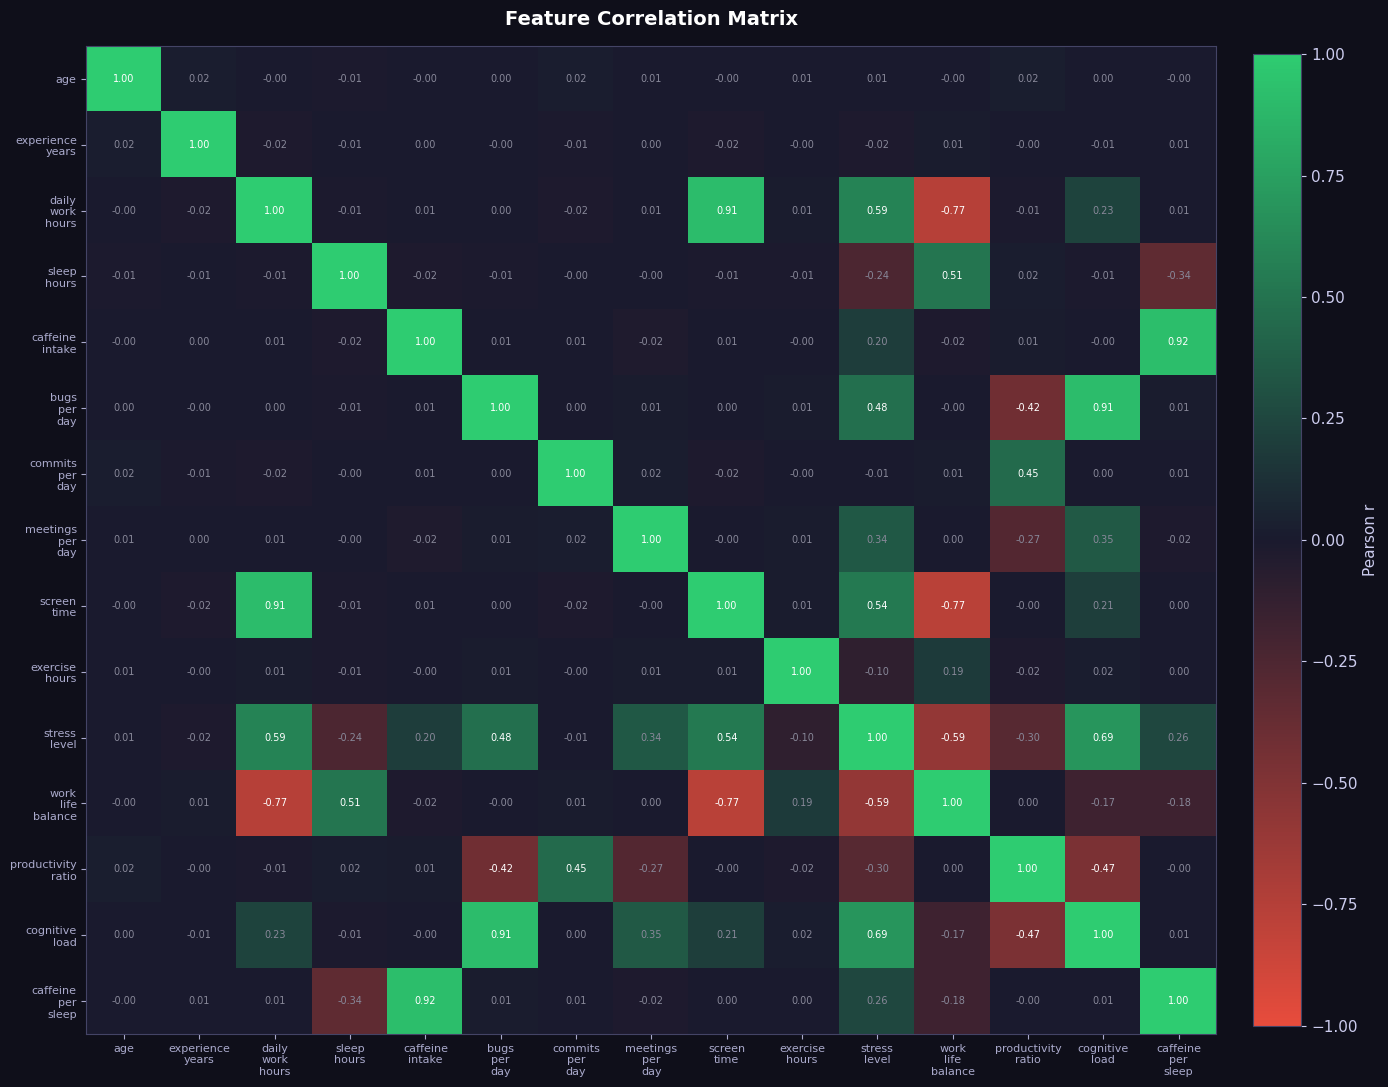

Saved: plot_04_correlation_heatmap.png


In [12]:
num_feat_cols = base_cols + ['work_life_balance','productivity_ratio','cognitive_load','caffeine_per_sleep']
corr = df[num_feat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor('#0f0f1a')

cmap = LinearSegmentedColormap.from_list('rb', ['#e74c3c','#1a1a2e','#2ecc71'])
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

labels = [c.replace('_', '\n') for c in corr.columns]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.4 else '#888899'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.set_label('Pearson r', color='#ccccee')
cbar.ax.yaxis.set_tick_params(color='#ccccee')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#ccccee')

ax.set_title('Feature Correlation Matrix', fontsize=14, color='#ffffff', pad=15)
plt.tight_layout()
plt.savefig('plot_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_04_correlation_heatmap.png')

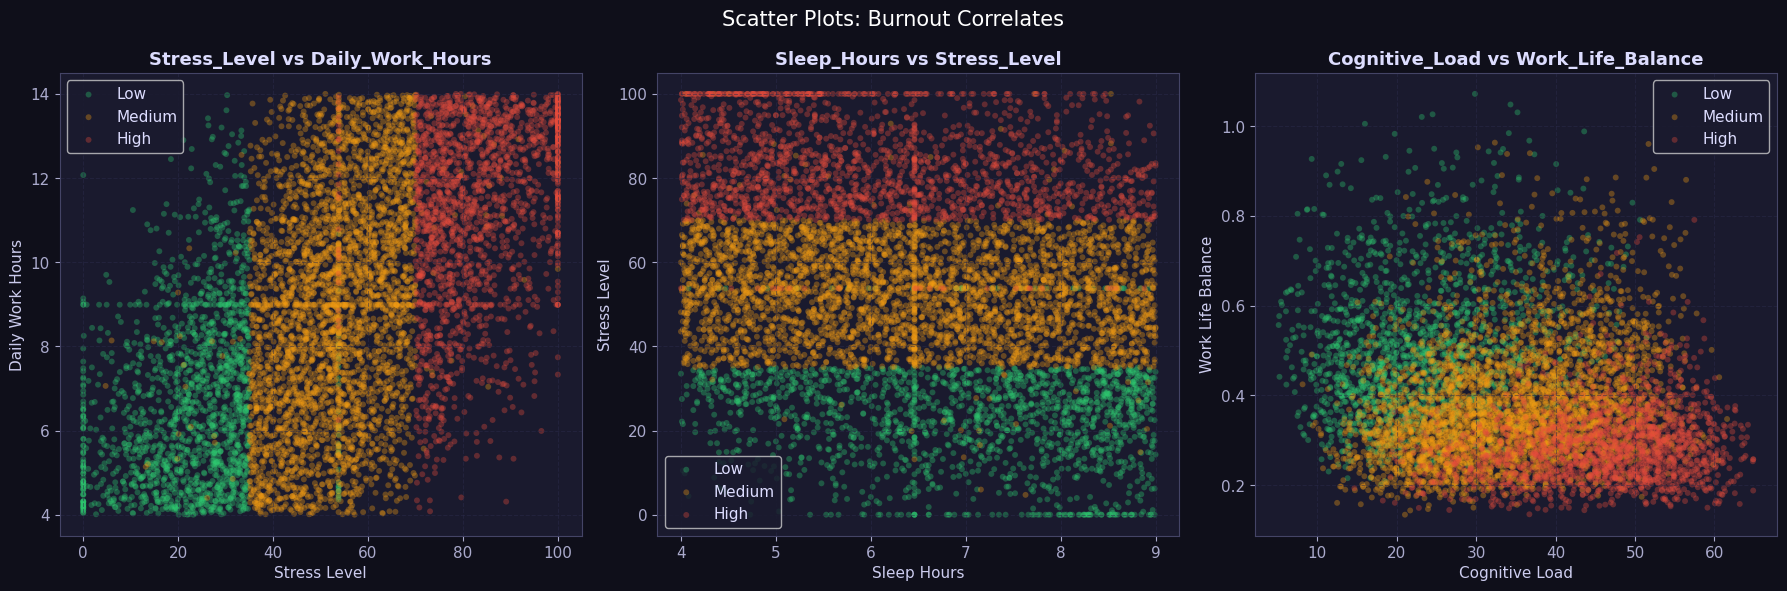

Saved: plot_05_scatterplots.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Scatter Plots: Burnout Correlates', fontsize=15, color='#ffffff')

scatter_pairs = [
    ('stress_level', 'daily_work_hours'),
    ('sleep_hours', 'stress_level'),
    ('cognitive_load', 'work_life_balance'),
]

for ax, (xcol, ycol) in zip(axes, scatter_pairs):
    for level in BURNOUT_ORDER:
        sub = df[df['burnout_level'] == level]
        ax.scatter(sub[xcol], sub[ycol], c=PALETTE[level], label=level,
                   alpha=0.35, s=18, edgecolors='none')
    ax.set_xlabel(xcol.replace('_', ' ').title())
    ax.set_ylabel(ycol.replace('_', ' ').title())
    ax.set_title(f'{xcol.title()} vs {ycol.title()}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('plot_05_scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_05_scatterplots.png')

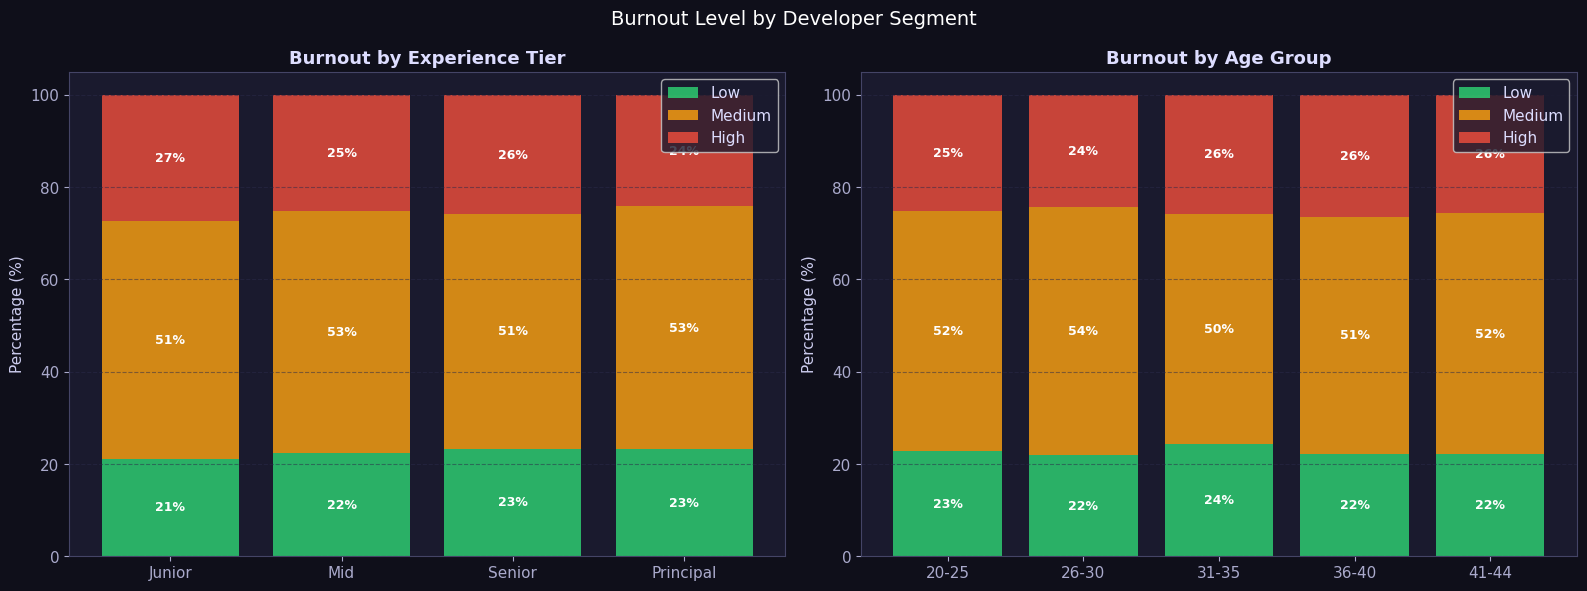

Saved: plot_06_stacked_bars.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Burnout Level by Developer Segment', fontsize=14, color='#ffffff')

for ax, group_col, title in zip(axes, ['exp_tier', 'age_group'],
                                  ['Experience Tier', 'Age Group']):
    ct = pd.crosstab(df[group_col], df['burnout_level'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct = ct_pct.reindex(columns=BURNOUT_ORDER, fill_value=0)

    bottom = np.zeros(len(ct_pct))
    for level in BURNOUT_ORDER:
        bars = ax.bar(ct_pct.index, ct_pct[level], bottom=bottom,
                      color=PALETTE[level], label=level, alpha=0.85)
        for bar, val in zip(bars, ct_pct[level]):
            if val > 5:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_y() + bar.get_height()/2,
                        f'{val:.0f}%', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
        bottom += ct_pct[level].values

    ax.set_ylabel('Percentage (%)')
    ax.set_title(f'Burnout by {title}')
    ax.legend(loc='upper right')
    ax.set_ylim(0, 105)
    ax.grid(axis='y')

plt.tight_layout()
plt.savefig('plot_06_stacked_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_06_stacked_bars.png')

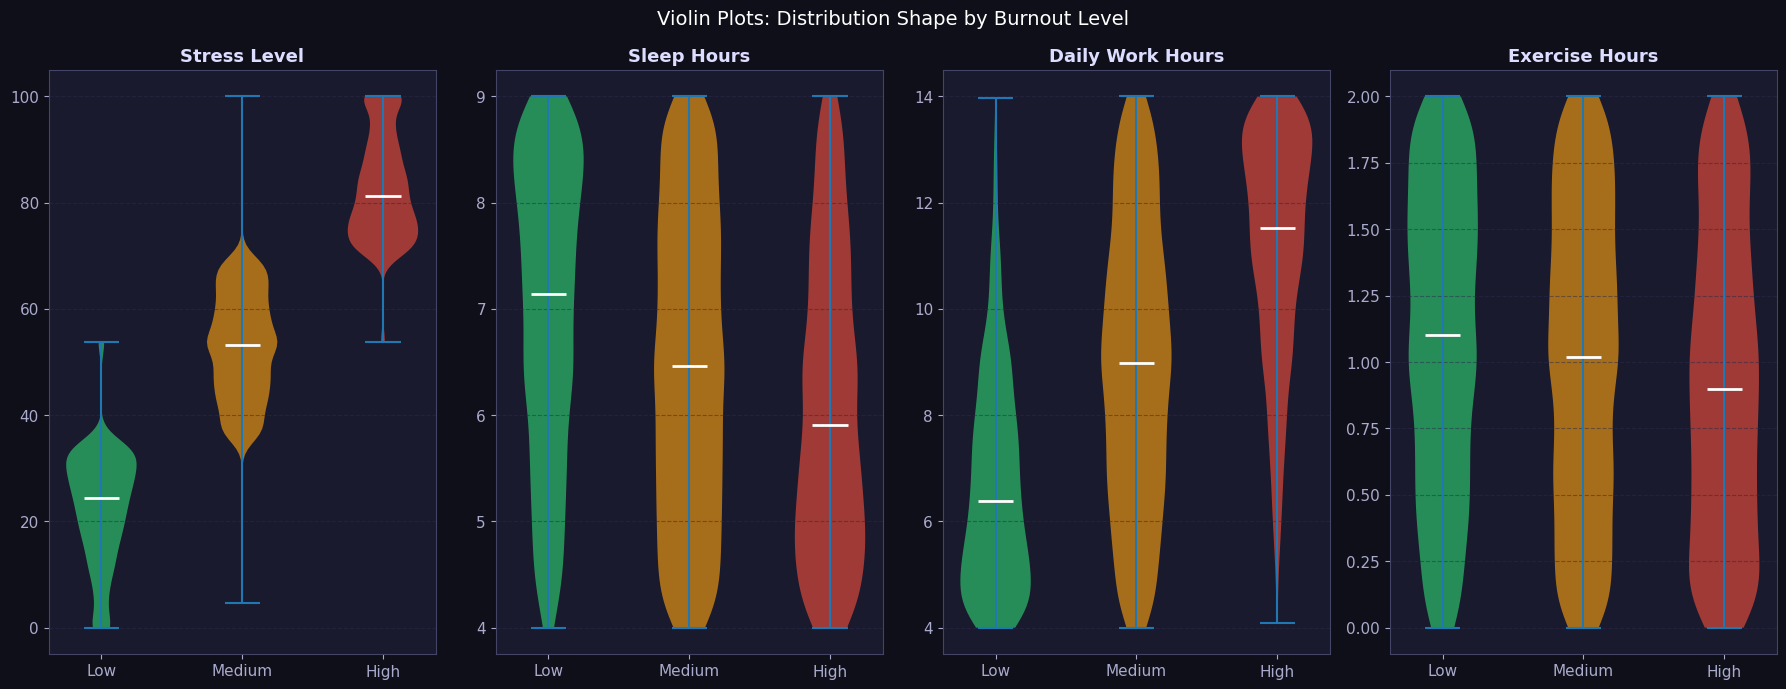

Saved: plot_07_violins.png


In [15]:
vio_cols = ['stress_level', 'sleep_hours', 'daily_work_hours', 'exercise_hours']
fig, axes = plt.subplots(1, 4, figsize=(18, 7))
fig.suptitle('Violin Plots: Distribution Shape by Burnout Level', fontsize=14, color='#ffffff')

for ax, col in zip(axes, vio_cols):
    data_by_level = [df[df['burnout_level'] == lvl][col].dropna().values for lvl in BURNOUT_ORDER]
    parts = ax.violinplot(data_by_level, positions=range(3),
                          showmedians=True, showextrema=True)
    for pc, level in zip(parts['bodies'], BURNOUT_ORDER):
        pc.set_facecolor(PALETTE[level])
        pc.set_alpha(0.65)
    parts['cmedians'].set_colors(['#ffffff']*3)
    parts['cmedians'].set_linewidth(2)
    ax.set_xticks(range(3))
    ax.set_xticklabels(BURNOUT_ORDER)
    ax.set_title(col.replace('_', ' ').title())
    ax.grid(axis='y')

plt.tight_layout()
plt.savefig('plot_07_violins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_07_violins.png')

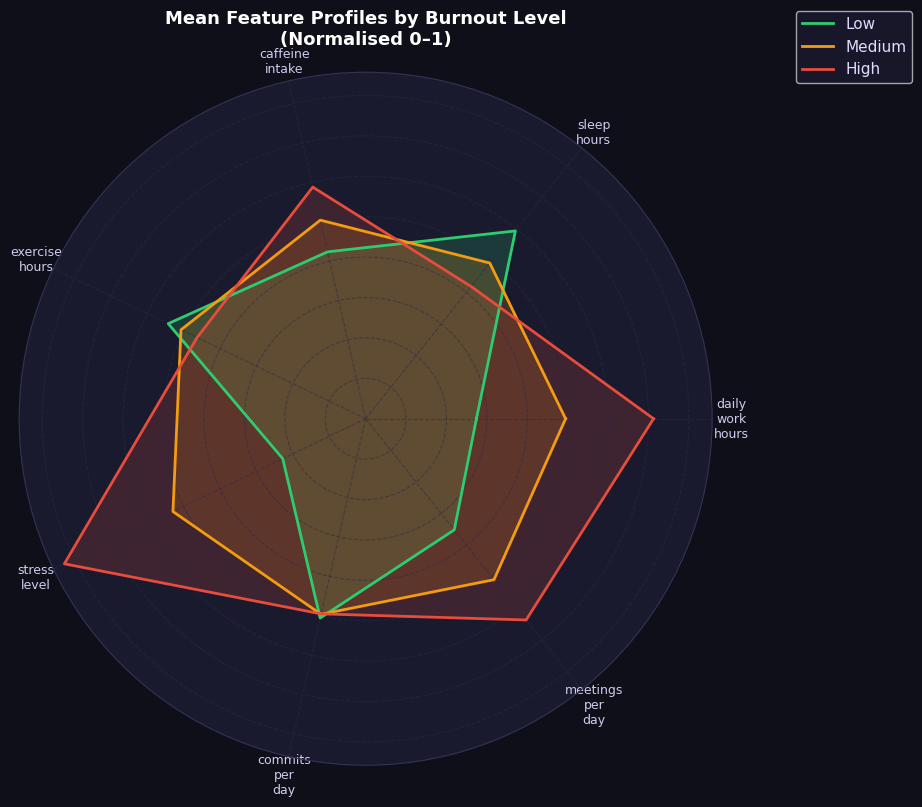

Saved: plot_08_radar.png


In [16]:
radar_cols = ['daily_work_hours','sleep_hours','caffeine_intake',
              'exercise_hours','stress_level','commits_per_day','meetings_per_day']

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[radar_cols] = scaler.fit_transform(df[radar_cols])

N = len(radar_cols)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

for level in BURNOUT_ORDER:
    vals = df_scaled[df_scaled['burnout_level'] == level][radar_cols].mean().values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=PALETTE[level], linewidth=2, label=level)
    ax.fill(angles, vals, color=PALETTE[level], alpha=0.18)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.replace('_','\n') for c in radar_cols], color='#ccccee', fontsize=9)
ax.set_yticklabels([])
ax.set_title('Mean Feature Profiles by Burnout Level\n(Normalised 0–1)', fontsize=13,
             color='#ffffff', pad=20)
ax.spines['polar'].set_color('#333355')
ax.grid(color='#2a2a4a', linestyle='--', alpha=0.5)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.savefig('plot_08_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_08_radar.png')

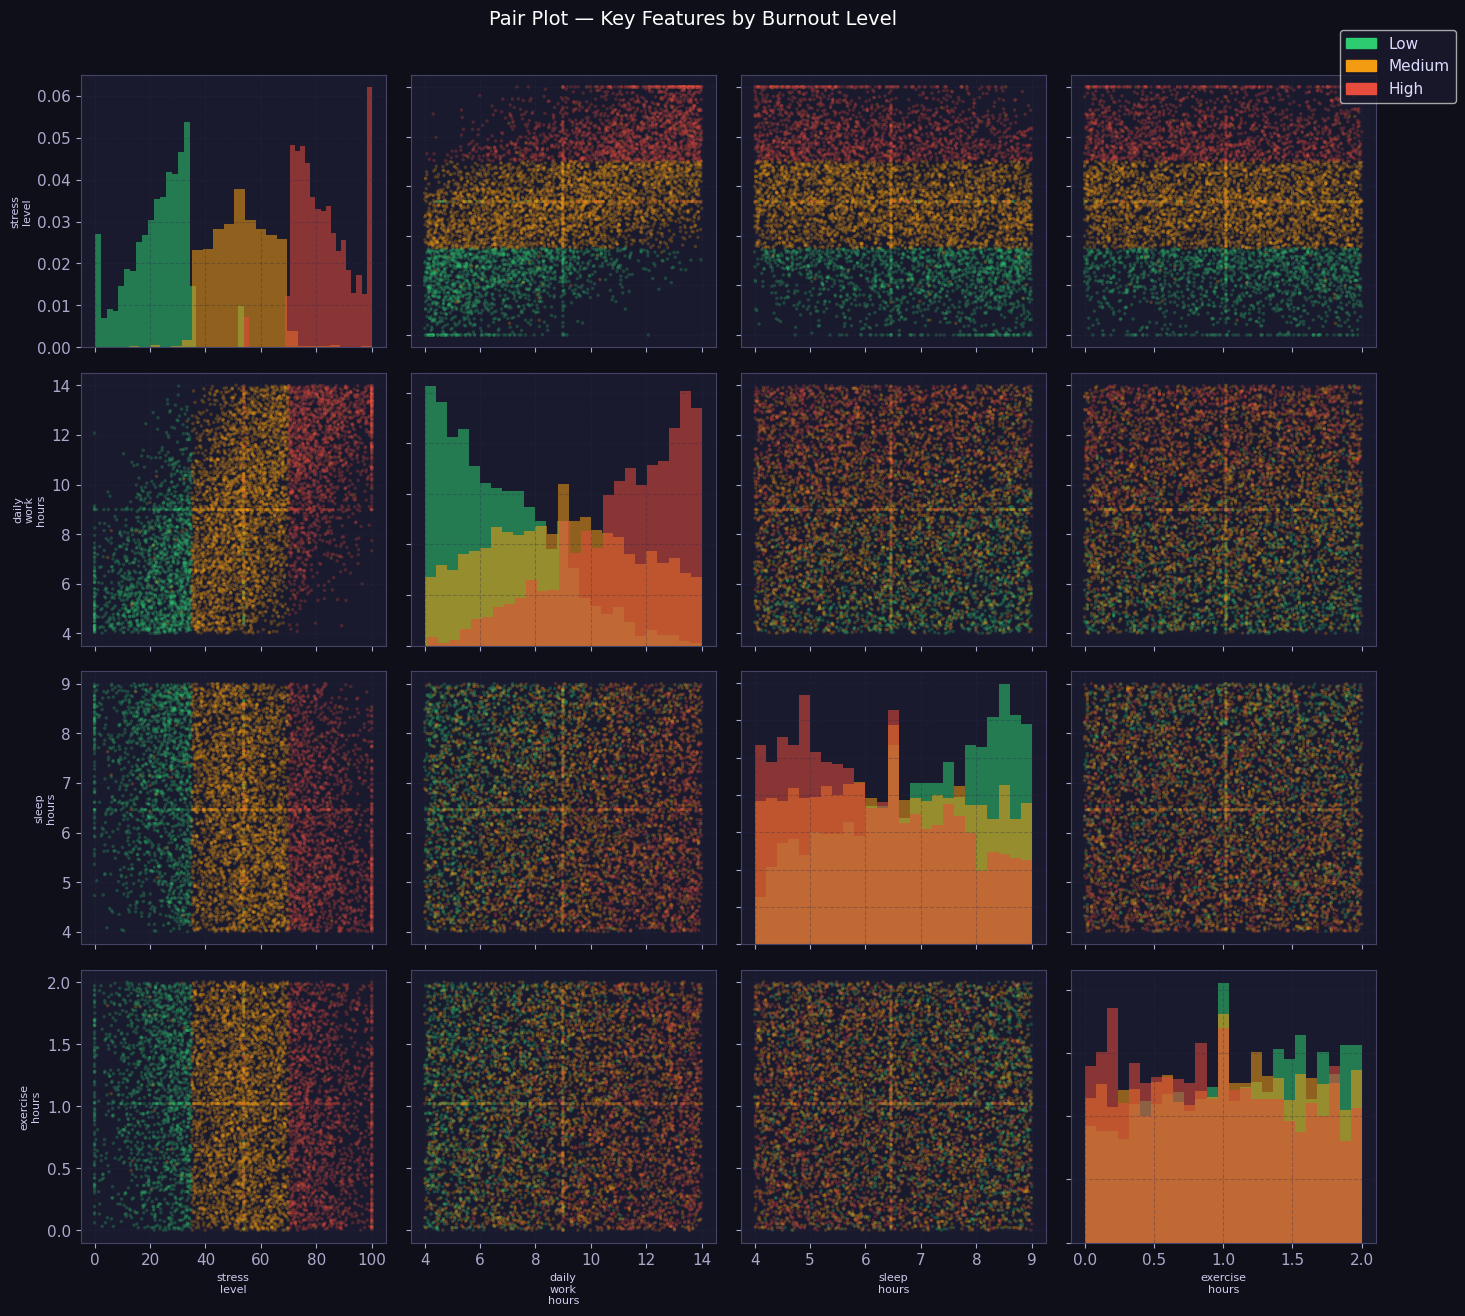

Saved: plot_09_pairplot.png


In [17]:
from matplotlib.patches import Ellipse
pair_cols = ['stress_level', 'daily_work_hours', 'sleep_hours', 'exercise_hours']
n = len(pair_cols)
fig, axes = plt.subplots(n, n, figsize=(14, 13))
fig.suptitle('Pair Plot — Key Features by Burnout Level', fontsize=14, color='#ffffff', y=1.01)

for i in range(n):
    for j in range(n):
        ax = axes[i][j]
        if i == j:
            for level in BURNOUT_ORDER:
                sub = df[df['burnout_level'] == level][pair_cols[i]]
                ax.hist(sub, bins=25, alpha=0.55, color=PALETTE[level], density=True)
        else:
            for level in BURNOUT_ORDER:
                sub = df[df['burnout_level'] == level]
                ax.scatter(sub[pair_cols[j]], sub[pair_cols[i]],
                           c=PALETTE[level], s=6, alpha=0.25, edgecolors='none')
        if i == n-1:
            ax.set_xlabel(pair_cols[j].replace('_','\n'), fontsize=8)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(pair_cols[i].replace('_','\n'), fontsize=8)
        else:
            ax.set_yticklabels([])
        ax.grid(True, alpha=0.3)

patches = [mpatches.Patch(color=PALETTE[l], label=l) for l in BURNOUT_ORDER]
fig.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.05, 1.0))
plt.tight_layout()
plt.savefig('plot_09_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_09_pairplot.png')

In [19]:
if PLOTLY_AVAILABLE:
    color_map = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
    fig_sun = px.sunburst(
        df,
        path=['exp_tier', 'age_group', 'burnout_level'],
        color='burnout_level',
        color_discrete_map=color_map,
        title='Burnout Hierarchy: Experience → Age → Level',
        template='plotly_dark'
    )
    fig_sun.show()

    fig_3d = px.scatter_3d(
        df.sample(2000, random_state=42),
        x='stress_level', y='daily_work_hours', z='sleep_hours',
        color='burnout_level',
        color_discrete_map=color_map,
        opacity=0.6,
        title='3D Scatter: Stress × Work Hours × Sleep',
        template='plotly_dark'
    )
    fig_3d.show()

    enc_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df['burnout_num'] = df['burnout_level'].map(enc_map)
    fig_par = px.parallel_coordinates(
        df.sample(2000, random_state=1),
        dimensions=['stress_level','daily_work_hours','sleep_hours',
                    'caffeine_intake','exercise_hours','commits_per_day'],
        color='burnout_num',
        color_continuous_scale=[(0,'#2ecc71'),(0.5,'#f39c12'),(1,'#e74c3c')],
        title='Parallel Coordinates — Feature Profiles by Burnout Level',
        template='plotly_dark'
    )
    fig_par.show()

    fig_box = px.box(
        df, x='burnout_level', y='stress_level',
        color='burnout_level',
        color_discrete_map=color_map,
        category_orders={'burnout_level': BURNOUT_ORDER},
        notched=True,
        points='outliers',
        title='Stress Level Distribution by Burnout Level',
        template='plotly_dark'
    )
    fig_box.show()

    fig_hist = px.histogram(
        df, x='stress_level', color='burnout_level',
        barmode='overlay', nbins=40,
        color_discrete_map=color_map,
        category_orders={'burnout_level': BURNOUT_ORDER},
        opacity=0.65,
        title='Stress Level Histogram by Burnout Level',
        template='plotly_dark'
    )
    fig_hist.show()

else:
    print('Install plotly to see interactive charts: pip install plotly')

## 5. Model Training

In [20]:
le = LabelEncoder()
le.fit(BURNOUT_ORDER)
y = le.transform(df['burnout_level'])

FEATURE_COLS = [
    'age','experience_years','daily_work_hours','sleep_hours',
    'caffeine_intake','bugs_per_day','commits_per_day',
    'meetings_per_day','screen_time','exercise_hours','stress_level',
    'work_life_balance','productivity_ratio','cognitive_load','caffeine_per_sleep'
]
X = df[FEATURE_COLS].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Class distribution in train: {dict(zip(le.classes_, np.bincount(y_train)))}')

Train: (5600, 15) | Test: (1400, 15)
Class distribution in train: {np.str_('High'): np.int64(1426), np.str_('Low'): np.int64(1274), np.str_('Medium'): np.int64(2900)}


In [21]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, C=1.0))
    ]),
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=12,
                                       random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                           max_depth=5, random_state=42))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=5, gamma='scale',
                    probability=True, random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=11))
    ]),
}

results = {}
for name, pipe in models.items():
    print(f'Training {name}...', end=' ', flush=True)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    roc  = roc_auc_score(y_test, y_prob, multi_class='ovr')
    results[name] = {'model': pipe, 'y_pred': y_pred, 'y_prob': y_prob,
                     'accuracy': acc, 'f1': f1, 'roc_auc': roc}
    print(f'Acc={acc:.4f} | F1={f1:.4f} | ROC-AUC={roc:.4f}')

Training Logistic Regression... Acc=0.9600 | F1=0.9600 | ROC-AUC=0.9884
Training Random Forest... Acc=0.9864 | F1=0.9864 | ROC-AUC=0.9945
Training Gradient Boosting... Acc=0.9871 | F1=0.9872 | ROC-AUC=0.9956
Training SVM (RBF)... Acc=0.9393 | F1=0.9393 | ROC-AUC=0.9871
Training KNN... Acc=0.8264 | F1=0.8256 | ROC-AUC=0.9453


## 6. Model Evaluation & Comparison

In [22]:
summary = pd.DataFrame([
    {'Model': k, 'Accuracy': v['accuracy'], 'F1 (weighted)': v['f1'], 'ROC-AUC (OvR)': v['roc_auc']}
    for k, v in results.items()
]).sort_values('ROC-AUC (OvR)', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

              Model  Accuracy  F1 (weighted)  ROC-AUC (OvR)
  Gradient Boosting  0.987143       0.987155       0.995592
      Random Forest  0.986429       0.986443       0.994542
Logistic Regression  0.960000       0.959990       0.988450
          SVM (RBF)  0.939286       0.939275       0.987052
                KNN  0.826429       0.825586       0.945253


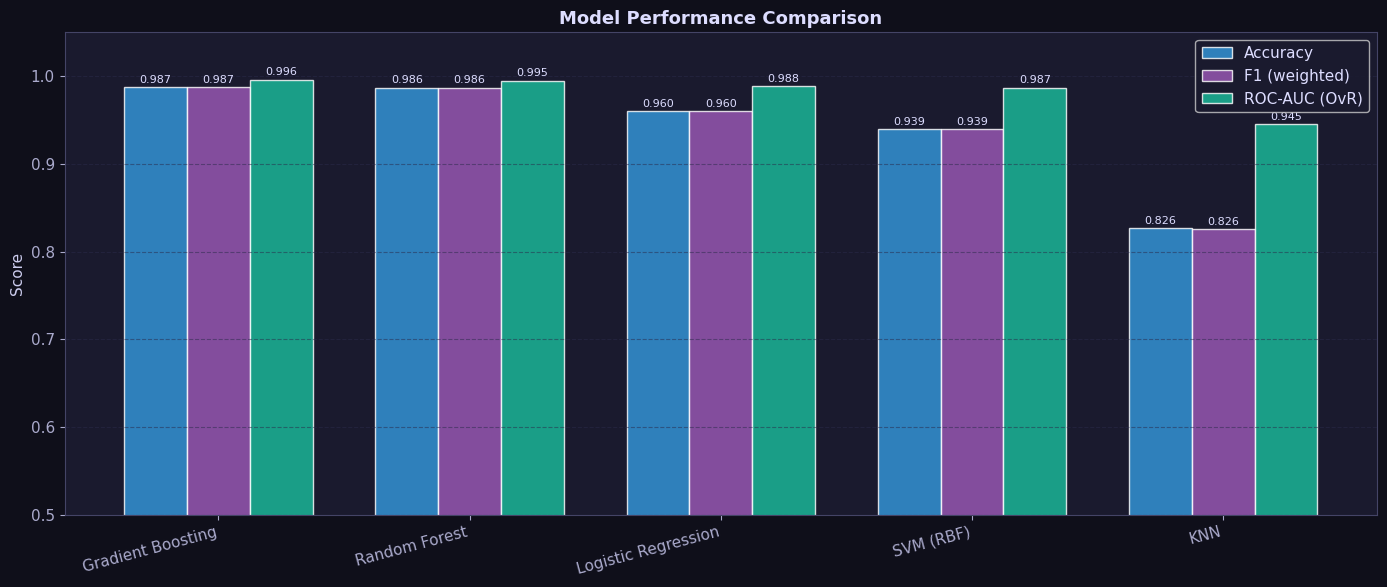

Saved: plot_10_model_comparison.png


In [23]:
metrics = ['Accuracy', 'F1 (weighted)', 'ROC-AUC (OvR)']
x = np.arange(len(summary))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bar_colors = ['#3498db', '#9b59b6', '#1abc9c']

for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    bars = ax.bar(x + i*width, summary[metric], width, label=metric,
                  color=color, alpha=0.82, edgecolor='#ffffff22')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8, color='#ddddff')

ax.set_xticks(x + width)
ax.set_xticklabels(summary['Model'], rotation=15, ha='right')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13)
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('plot_10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_10_model_comparison.png')

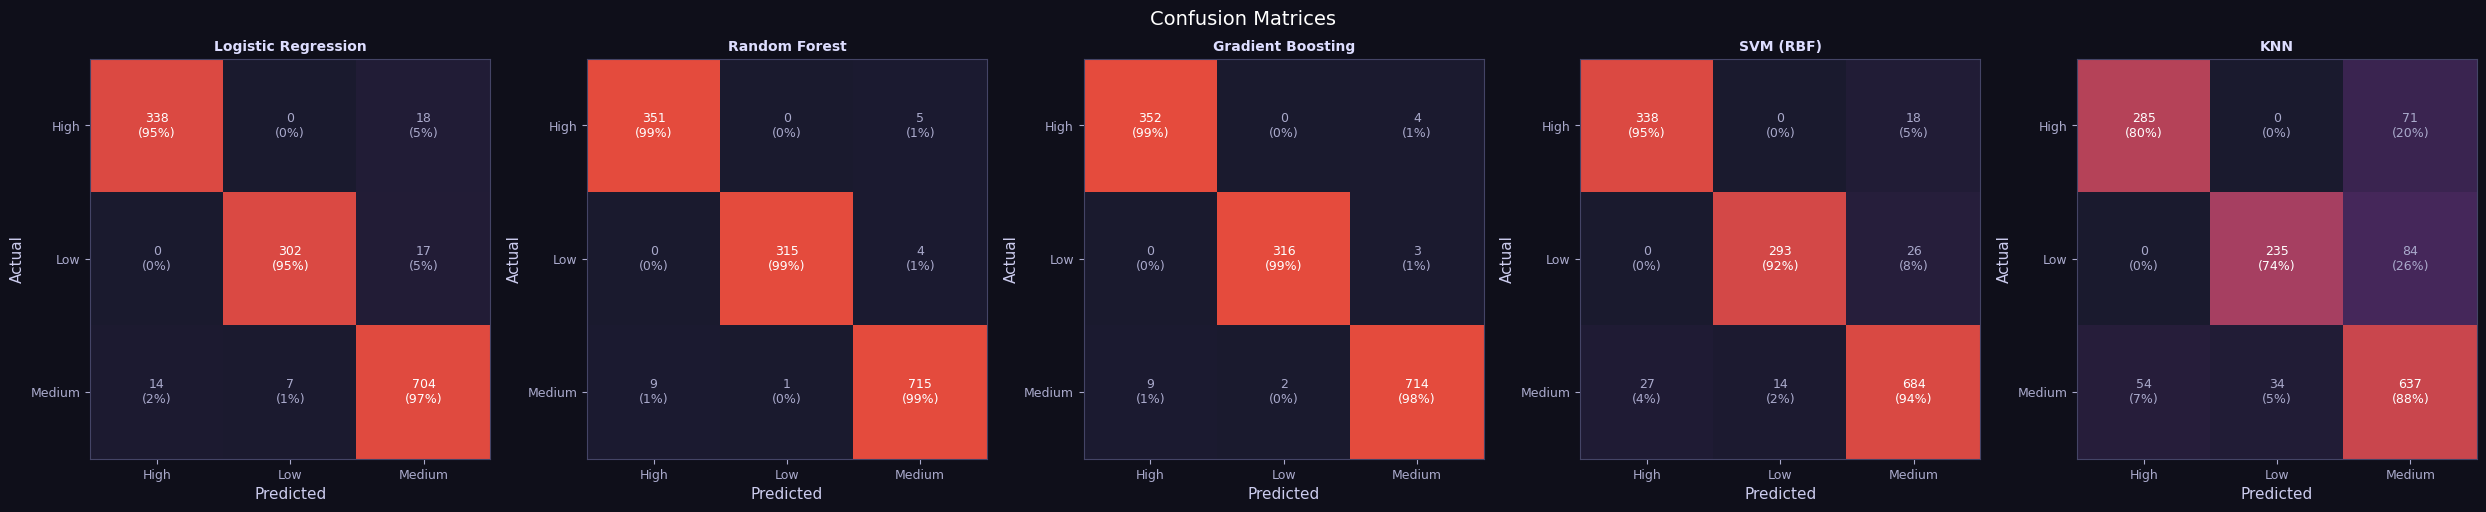

Saved: plot_11_confusion_matrices.png


In [24]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))
fig.suptitle('Confusion Matrices', fontsize=14, color='#ffffff')

cmap_cm = LinearSegmentedColormap.from_list('cm', ['#1a1a2e','#6c3483','#e74c3c'])

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap=cmap_cm, vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.0%})',
                    ha='center', va='center',
                    color='white' if cm_norm[i,j] > 0.4 else '#aaaacc',
                    fontsize=9)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(le.classes_, fontsize=9)
    ax.set_yticklabels(le.classes_, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.savefig('plot_11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_11_confusion_matrices.png')

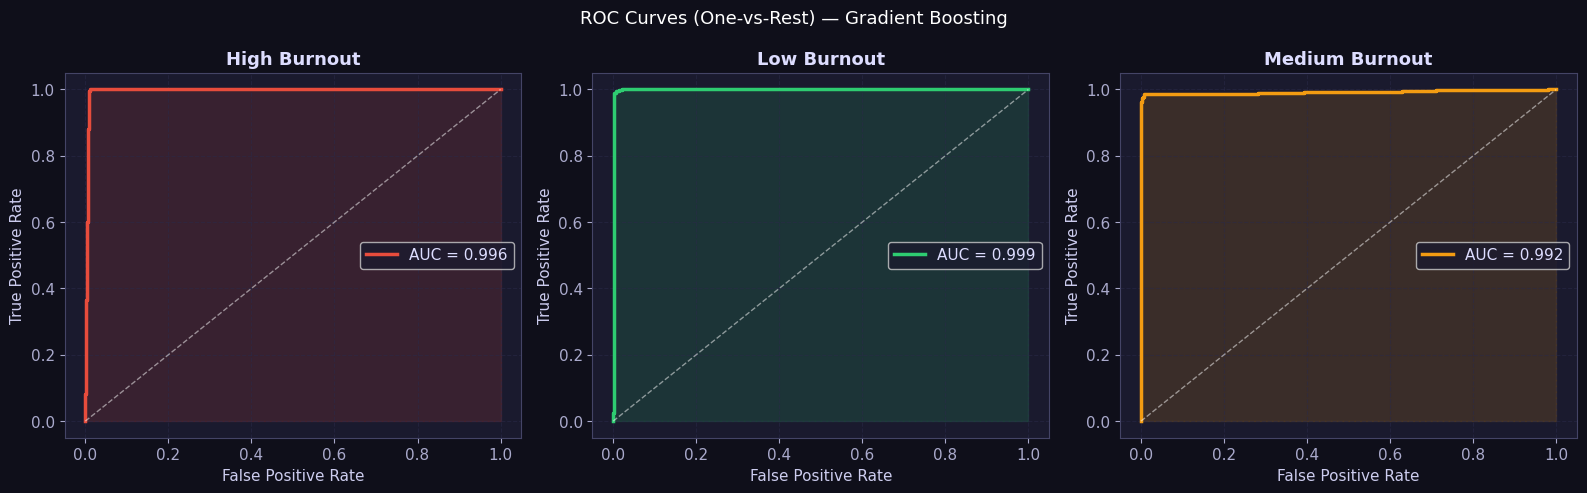

Saved: plot_12_roc_curves.png


In [25]:
best_name = summary.iloc[0]['Model']
best_res  = results[best_name]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'ROC Curves (One-vs-Rest) — {best_name}', fontsize=13, color='#ffffff')

for i, (level, ax) in enumerate(zip(le.classes_, axes)):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), best_res['y_prob'][:, i])
    auc_val = roc_auc_score((y_test == i).astype(int), best_res['y_prob'][:, i])
    ax.plot(fpr, tpr, color=PALETTE[level], lw=2.5, label=f'AUC = {auc_val:.3f}')
    ax.plot([0,1],[0,1], 'w--', lw=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.15, color=PALETTE[level])
    ax.set_title(f'{level} Burnout')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('plot_12_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_12_roc_curves.png')

Logistic Regression: mean=0.9550 ± 0.0073
Random Forest: mean=0.9831 ± 0.0045
Gradient Boosting: mean=0.9843 ± 0.0037
SVM (RBF): mean=0.9363 ± 0.0074
KNN: mean=0.8326 ± 0.0131


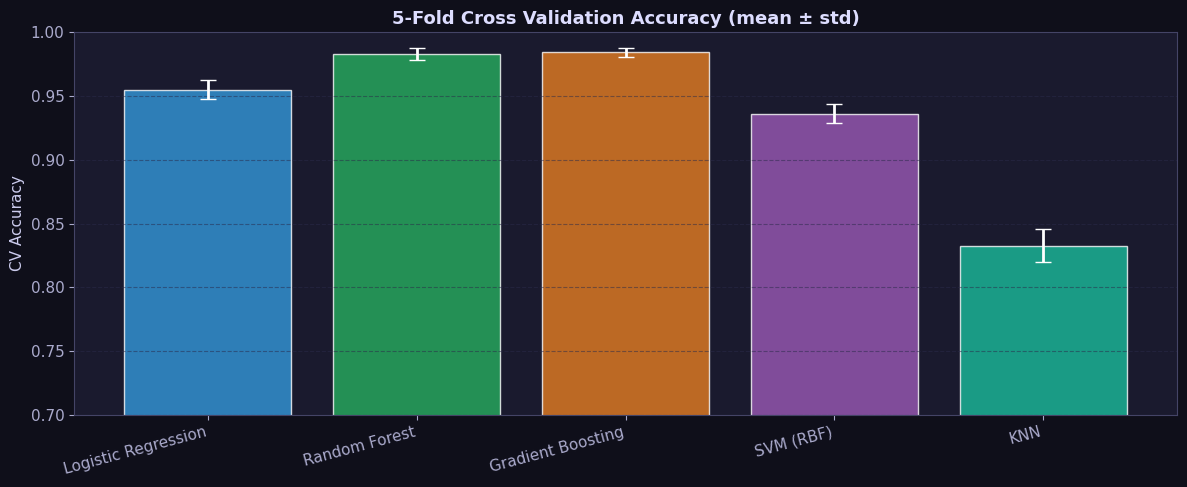

Saved: plot_13_cv_scores.png


In [26]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: mean={scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
colors_cv = ['#3498db','#27ae60','#e67e22','#9b59b6','#1abc9c']
for i, (name, scores) in enumerate(cv_results.items()):
    ax.bar(i, scores.mean(), color=colors_cv[i], alpha=0.8, label=name,
           edgecolor='#ffffff22')
    ax.errorbar(i, scores.mean(), yerr=scores.std(), fmt='none',
                color='white', capsize=6, linewidth=2)
ax.set_xticks(range(len(cv_results)))
ax.set_xticklabels(cv_results.keys(), rotation=15, ha='right')
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('CV Accuracy')
ax.set_title('5-Fold Cross Validation Accuracy (mean ± std)')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('plot_13_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_13_cv_scores.png')

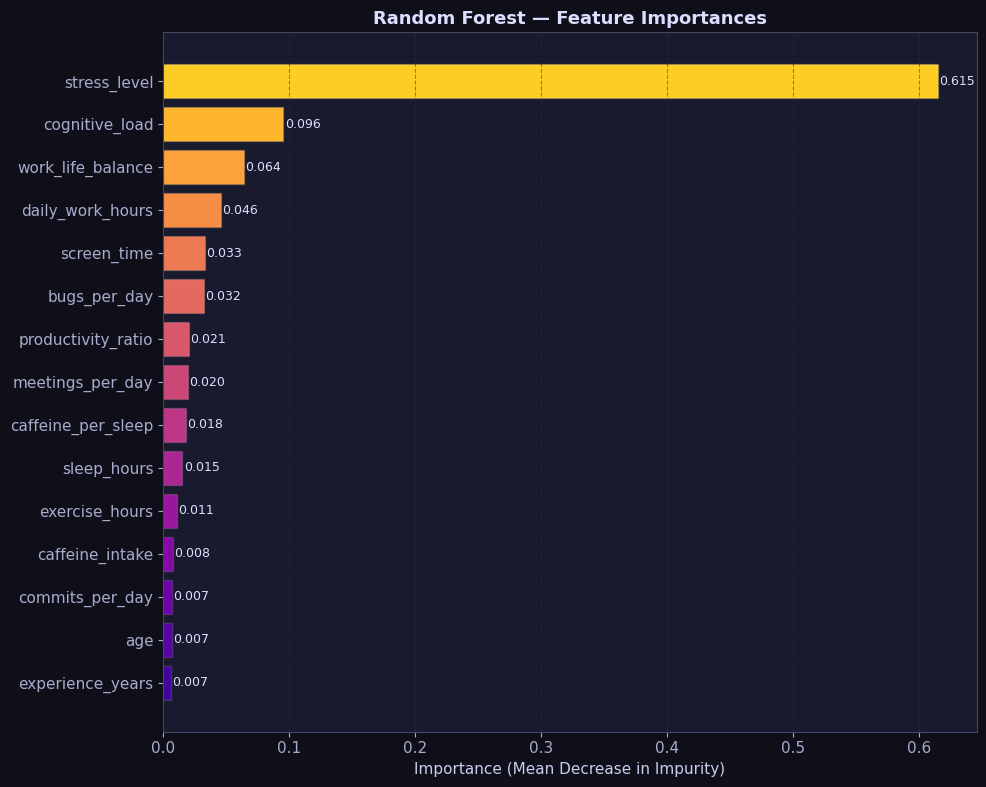

Saved: plot_14_feature_importance.png


In [27]:
rf_pipe = results['Random Forest']['model']
importances = rf_pipe.named_steps['clf'].feature_importances_
fi_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(fi_df['feature'], fi_df['importance'],
               color=plt.cm.plasma(np.linspace(0.1, 0.9, len(fi_df))),
               edgecolor='#ffffff22')
for bar, val in zip(bars, fi_df['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='#ddddff')
ax.set_xlabel('Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest — Feature Importances')
ax.grid(axis='x')
plt.tight_layout()
plt.savefig('plot_14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_14_feature_importance.png')

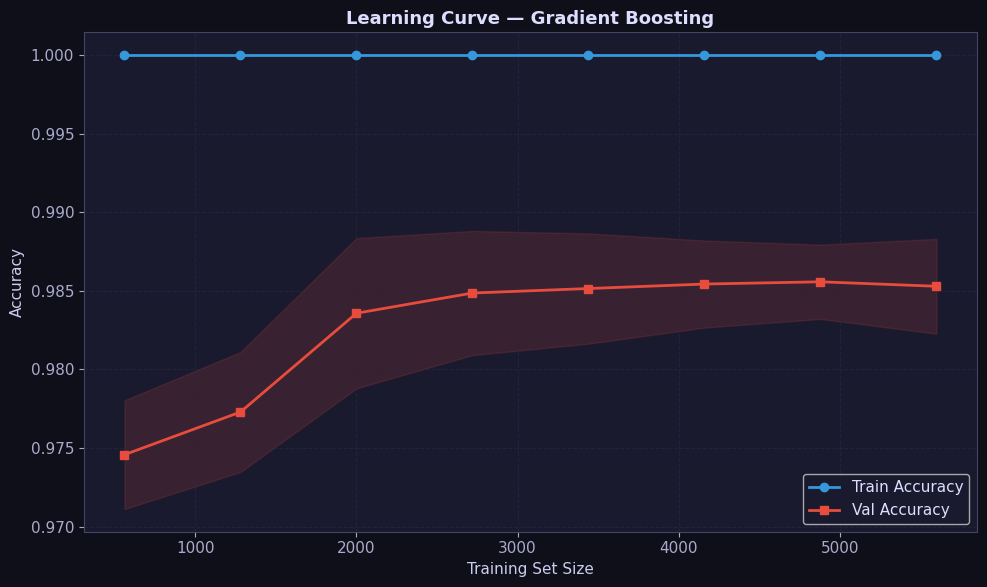

Saved: plot_15_learning_curve.png


In [28]:
from sklearn.model_selection import learning_curve

best_pipe = results[best_name]['model']
train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#3498db',
        lw=2, label='Train Accuracy')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.15, color='#3498db')
ax.plot(train_sizes, val_scores.mean(axis=1), 's-', color='#e74c3c',
        lw=2, label='Val Accuracy')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.15, color='#e74c3c')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_title(f'Learning Curve — {best_name}')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('plot_15_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_15_learning_curve.png')

## 7. Plotly Real-Time Analytical Dashboard

In [29]:
if PLOTLY_AVAILABLE:
    color_map = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
    counts = df['burnout_level'].value_counts().reindex(BURNOUT_ORDER)
    grp = df.groupby('burnout_level')[[
        'stress_level','daily_work_hours','sleep_hours',
        'exercise_hours','caffeine_intake'
    ]].mean().reindex(BURNOUT_ORDER)

    fig_dash = make_subplots(
        rows=3, cols=3,
        subplot_titles=[
            'Burnout Distribution', 'Stress vs Work Hours', 'Sleep by Burnout',
            'Feature Means by Burnout', 'Exercise Distribution', 'Commits vs Bugs',
            'Cognitive Load vs Burnout', 'Caffeine vs Stress', 'Productivity Ratio'
        ],
        specs=[
            [{'type':'pie'}, {'type':'scatter'}, {'type':'box'}],
            [{'type':'bar'},  {'type':'violin'},  {'type':'scatter'}],
            [{'type':'box'},  {'type':'scatter'}, {'type':'histogram'}]
        ]
    )

    fig_dash.add_trace(go.Pie(
        labels=BURNOUT_ORDER, values=counts.values,
        marker_colors=[color_map[l] for l in BURNOUT_ORDER],
        hole=0.35, name=''
    ), row=1, col=1)

    for level in BURNOUT_ORDER:
        sub = df[df['burnout_level'] == level].sample(min(500, len(df)), random_state=7)
        fig_dash.add_trace(go.Scatter(
            x=sub['stress_level'], y=sub['daily_work_hours'],
            mode='markers', name=level, marker=dict(color=color_map[level], size=4, opacity=0.5),
            showlegend=(level == 'High')
        ), row=1, col=2)

    for level in BURNOUT_ORDER:
        fig_dash.add_trace(go.Box(
            y=df[df['burnout_level'] == level]['sleep_hours'],
            name=level, marker_color=color_map[level], showlegend=False
        ), row=1, col=3)

    for metric in ['stress_level', 'daily_work_hours', 'caffeine_intake']:
        fig_dash.add_trace(go.Bar(
            x=BURNOUT_ORDER, y=grp[metric], name=metric.replace('_',' ').title()
        ), row=2, col=1)

    for level in BURNOUT_ORDER:
        fig_dash.add_trace(go.Violin(
            y=df[df['burnout_level'] == level]['exercise_hours'],
            name=level, fillcolor=color_map[level], line_color='white',
            opacity=0.7, showlegend=False, box_visible=True
        ), row=2, col=2)

    for level in BURNOUT_ORDER:
        sub = df[df['burnout_level'] == level].sample(min(500, len(df)), random_state=8)
        fig_dash.add_trace(go.Scatter(
            x=sub['bugs_per_day'], y=sub['commits_per_day'],
            mode='markers', name=level,
            marker=dict(color=color_map[level], size=4, opacity=0.5),
            showlegend=False
        ), row=2, col=3)

    for level in BURNOUT_ORDER:
        fig_dash.add_trace(go.Box(
            y=df[df['burnout_level'] == level]['cognitive_load'],
            name=level, marker_color=color_map[level], showlegend=False
        ), row=3, col=1)

    for level in BURNOUT_ORDER:
        sub = df[df['burnout_level'] == level].sample(min(400, len(df)), random_state=9)
        fig_dash.add_trace(go.Scatter(
            x=sub['caffeine_intake'], y=sub['stress_level'],
            mode='markers', name=level,
            marker=dict(color=color_map[level], size=4, opacity=0.5),
            showlegend=False
        ), row=3, col=3)

    for level in BURNOUT_ORDER:
        fig_dash.add_trace(go.Histogram(
            x=df[df['burnout_level'] == level]['productivity_ratio'],
            name=level, opacity=0.6,
            marker_color=color_map[level], showlegend=False
        ), row=3, col=3)

    fig_dash.update_layout(
        height=1100, width=1300,
        title_text='🔥 Developer Burnout — Real-Time Analytical Dashboard',
        title_font_size=18,
        template='plotly_dark',
        showlegend=True,
        barmode='group'
    )
    fig_dash.show()
    fig_dash.write_html('dashboard.html')
    print('Dashboard saved to: dashboard.html')
else:
    print('Plotly not available — install with: pip install plotly')

Dashboard saved to: dashboard.html


## 8. PostgreSQL Setup File Generation

In [30]:
sql = '''-- ==========================================================
-- Developer Burnout Analytics — PostgreSQL Setup
-- Run: psql -U <user> -d <dbname> -f burnout_setup.sql
-- ==========================================================

-- Drop & recreate schema
DROP TABLE IF EXISTS developer_burnout CASCADE;

CREATE TABLE developer_burnout (
    id                   SERIAL PRIMARY KEY,
    age                  NUMERIC(5,2),
    experience_years     NUMERIC(5,2),
    daily_work_hours     NUMERIC(5,2),
    sleep_hours          NUMERIC(5,2),
    caffeine_intake      NUMERIC(6,2),
    bugs_per_day         NUMERIC(6,2),
    commits_per_day      NUMERIC(6,2),
    meetings_per_day     NUMERIC(5,2),
    screen_time          NUMERIC(5,2),
    exercise_hours       NUMERIC(5,2),
    stress_level         NUMERIC(6,2),
    burnout_level        VARCHAR(10) CHECK(burnout_level IN (\'Low\',\'Medium\',\'High\')),
    work_life_balance    NUMERIC(8,4),
    productivity_ratio   NUMERIC(8,4),
    cognitive_load       NUMERIC(8,4),
    caffeine_per_sleep   NUMERIC(8,4),
    exp_tier             VARCHAR(15),
    age_group            VARCHAR(10),
    created_at           TIMESTAMPTZ DEFAULT NOW()
);

-- Indexes for dashboard queries
CREATE INDEX idx_burnout_level    ON developer_burnout(burnout_level);
CREATE INDEX idx_stress           ON developer_burnout(stress_level);
CREATE INDEX idx_exp_tier         ON developer_burnout(exp_tier);
CREATE INDEX idx_age_group        ON developer_burnout(age_group);

-- ── Analytical Views ───────────────────────────────────────────────────────

-- Summary stats per burnout level
CREATE OR REPLACE VIEW v_burnout_summary AS
SELECT
    burnout_level,
    COUNT(*) AS total_developers,
    ROUND(AVG(stress_level)::numeric, 2)       AS avg_stress,
    ROUND(AVG(daily_work_hours)::numeric, 2)   AS avg_work_hours,
    ROUND(AVG(sleep_hours)::numeric, 2)        AS avg_sleep,
    ROUND(AVG(exercise_hours)::numeric, 2)     AS avg_exercise,
    ROUND(AVG(caffeine_intake)::numeric, 2)    AS avg_caffeine,
    ROUND(AVG(commits_per_day)::numeric, 2)    AS avg_commits,
    ROUND(AVG(bugs_per_day)::numeric, 2)       AS avg_bugs,
    ROUND(AVG(meetings_per_day)::numeric, 2)   AS avg_meetings,
    ROUND(AVG(cognitive_load)::numeric, 2)     AS avg_cognitive_load,
    ROUND(AVG(work_life_balance)::numeric, 4)  AS avg_wlb_score
FROM developer_burnout
GROUP BY burnout_level
ORDER BY CASE burnout_level WHEN \'Low\' THEN 1 WHEN \'Medium\' THEN 2 ELSE 3 END;

-- Burnout distribution by experience tier
CREATE OR REPLACE VIEW v_burnout_by_experience AS
SELECT
    exp_tier,
    burnout_level,
    COUNT(*) AS cnt,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY exp_tier), 1) AS pct
FROM developer_burnout
GROUP BY exp_tier, burnout_level
ORDER BY exp_tier, burnout_level;

-- Burnout distribution by age group
CREATE OR REPLACE VIEW v_burnout_by_age AS
SELECT
    age_group,
    burnout_level,
    COUNT(*) AS cnt,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY age_group), 1) AS pct
FROM developer_burnout
GROUP BY age_group, burnout_level
ORDER BY age_group, burnout_level;

-- High-risk developers (High burnout + stress > 75)
CREATE OR REPLACE VIEW v_high_risk_developers AS
SELECT
    id, age, experience_years, exp_tier, age_group,
    stress_level, daily_work_hours, sleep_hours,
    exercise_hours, cognitive_load, work_life_balance
FROM developer_burnout
WHERE burnout_level = \'High\' AND stress_level > 75
ORDER BY stress_level DESC;

-- Correlation summary (avg values for dashboard KPIs)
CREATE OR REPLACE VIEW v_kpi_summary AS
SELECT
    COUNT(*)                                            AS total_records,
    ROUND(AVG(stress_level)::numeric, 1)               AS overall_avg_stress,
    ROUND(AVG(sleep_hours)::numeric, 2)                AS overall_avg_sleep,
    ROUND(AVG(daily_work_hours)::numeric, 2)           AS overall_avg_work_hours,
    ROUND(AVG(exercise_hours)::numeric, 2)             AS overall_avg_exercise,
    COUNT(*) FILTER(WHERE burnout_level=\'High\')      AS high_burnout_count,
    COUNT(*) FILTER(WHERE burnout_level=\'Medium\')    AS medium_burnout_count,
    COUNT(*) FILTER(WHERE burnout_level=\'Low\')       AS low_burnout_count,
    ROUND(100.0 * COUNT(*) FILTER(WHERE burnout_level=\'High\') / COUNT(*), 1) AS high_burnout_pct
FROM developer_burnout;

-- ── COPY command to bulk-load CSV ─────────────────────────────────────────
-- Update the path below before running:
-- \\COPY developer_burnout(
--     age, experience_years, daily_work_hours, sleep_hours, caffeine_intake,
--     bugs_per_day, commits_per_day, meetings_per_day, screen_time,
--     exercise_hours, stress_level, burnout_level
-- )
-- FROM \'/absolute/path/to/developer_burnout_dataset_7000.csv\'
-- WITH (FORMAT CSV, HEADER true, NULL \'\');

-- After loading, populate engineered columns:
UPDATE developer_burnout SET
    work_life_balance  = (sleep_hours + exercise_hours) / NULLIF(daily_work_hours + screen_time, 0),
    productivity_ratio = commits_per_day / NULLIF(bugs_per_day + meetings_per_day + 1, 0),
    cognitive_load     = bugs_per_day * 2 + meetings_per_day * 1.5 + daily_work_hours,
    caffeine_per_sleep = caffeine_intake / NULLIF(sleep_hours, 0),
    exp_tier = CASE
        WHEN experience_years <= 2  THEN \'Junior\'
        WHEN experience_years <= 7  THEN \'Mid\'
        WHEN experience_years <= 14 THEN \'Senior\'
        ELSE \'Principal\'
    END,
    age_group = CASE
        WHEN age BETWEEN 20 AND 25 THEN \'20-25\'
        WHEN age BETWEEN 26 AND 30 THEN \'26-30\'
        WHEN age BETWEEN 31 AND 35 THEN \'31-35\'
        WHEN age BETWEEN 36 AND 40 THEN \'36-40\'
        ELSE \'41-44\'
    END
WHERE work_life_balance IS NULL;

-- Verify
SELECT * FROM v_kpi_summary;
SELECT * FROM v_burnout_summary;
'''

with open('burnout_setup.sql', 'w') as f:
    f.write(sql)

print('PostgreSQL setup file written: burnout_setup.sql')

PostgreSQL setup file written: burnout_setup.sql


In [31]:
export_cols = [
    'age','experience_years','daily_work_hours','sleep_hours','caffeine_intake',
    'bugs_per_day','commits_per_day','meetings_per_day','screen_time',
    'exercise_hours','stress_level','burnout_level',
    'work_life_balance','productivity_ratio','cognitive_load',
    'caffeine_per_sleep','exp_tier','age_group'
]
df[export_cols].to_csv('developer_burnout_cleaned.csv', index=False)
print(f'Cleaned dataset exported: developer_burnout_cleaned.csv ({len(df)} rows)')

Cleaned dataset exported: developer_burnout_cleaned.csv (7000 rows)


## 9. Final Model Summary & Recommendations

In [32]:
print(f'Dataset : 7,000 records × 12 original features')
print(f'After cleaning: {len(df)} records (removed fully-null rows)')
print(f'Engineered features added: 6')
print(f'Target classes: Low / Medium / High')
print()
print('Best Model (by ROC-AUC):')
best_row = summary.iloc[0]
print(f"  → {best_row['Model']}")
print(f"    Accuracy  : {best_row['Accuracy']:.4f}")
print(f"    F1        : {best_row['F1 (weighted)']:.4f}")
print(f"    ROC-AUC   : {best_row['ROC-AUC (OvR)']:.4f}")
print()
print('Top 3 Burnout Predictors (RF importance):')
top3 = fi_df.sort_values('importance', ascending=False).head(3)
for _, row in top3.iterrows():
    print(f"  {row['feature']:25s} : {row['importance']:.4f}")
print()
print('Output files:')
for f in [
    'plot_01_burnout_distribution.png', 'plot_02_feature_histograms.png',
    'plot_03_boxplots.png', 'plot_04_correlation_heatmap.png',
    'plot_05_scatterplots.png', 'plot_06_stacked_bars.png',
    'plot_07_violins.png', 'plot_08_radar.png', 'plot_09_pairplot.png',
    'plot_10_model_comparison.png', 'plot_11_confusion_matrices.png',
    'plot_12_roc_curves.png', 'plot_13_cv_scores.png',
    'plot_14_feature_importance.png', 'plot_15_learning_curve.png',
    'dashboard.html', 'burnout_setup.sql', 'developer_burnout_cleaned.csv'
]:
    print(f'  ✓ {f}')

Dataset : 7,000 records × 12 original features
After cleaning: 7000 records (removed fully-null rows)
Engineered features added: 6
Target classes: Low / Medium / High

Best Model (by ROC-AUC):
  → Gradient Boosting
    Accuracy  : 0.9871
    F1        : 0.9872
    ROC-AUC   : 0.9956

Top 3 Burnout Predictors (RF importance):
  stress_level              : 0.6154
  cognitive_load            : 0.0956
  work_life_balance         : 0.0638

Output files:
  ✓ plot_01_burnout_distribution.png
  ✓ plot_02_feature_histograms.png
  ✓ plot_03_boxplots.png
  ✓ plot_04_correlation_heatmap.png
  ✓ plot_05_scatterplots.png
  ✓ plot_06_stacked_bars.png
  ✓ plot_07_violins.png
  ✓ plot_08_radar.png
  ✓ plot_09_pairplot.png
  ✓ plot_10_model_comparison.png
  ✓ plot_11_confusion_matrices.png
  ✓ plot_12_roc_curves.png
  ✓ plot_13_cv_scores.png
  ✓ plot_14_feature_importance.png
  ✓ plot_15_learning_curve.png
  ✓ dashboard.html
  ✓ burnout_setup.sql
  ✓ developer_burnout_cleaned.csv
